# Data Preprocessing and Augmentation 

first, we want to save the t2, mask, and noise pair into the json file.
json file also contains the t2, mask, and noise's original shape (& depth).

In [ ]:
from models.process_data.pair import *

# the pairs mapping has been 
create_and_save_pairs(
    t2_dir='/home/smooi/Desktop/toast/data/toast_pipe_data/t2stack',
    mask_dir='/home/smooi/Desktop/toast/data/toast_pipe_data/mask',
    train_txt='/home/smooi/Desktop/toast/data/toast_pipe_data/train.txt',
    val_txt='/home/smooi/Desktop/toast/data/toast_pipe_data/val.txt',
    test_txt='/home/smooi/Desktop/toast/data/toast_pipe_data/test.txt',
    noise_dir = '/home/smooi/Desktop/toast/noise_augmentation/processed_noise',
    output_file='/home/smooi/Desktop/mre_segmentation/data/pairs_mapping.json'
)

second, we will preprocess it and saved into the pickle file. We will preprocess the size for noise, 

In [1]:
from models.process_data.pair import *
preprocess_and_save_as_dict(
        pairs_file='/home/smooi/Desktop/mre_segmentation/data/pairs_mapping.json',
        output_dir='/home/smooi/Desktop/mre_segmentation/data',
        target_spacing=(1.5, 1.5, 1.5),
        target_size=(128, 128, 64),
        is_2d=False
    )


PREPROCESSING WITH DICTIONARY FORMAT

--- Processing train split (81 subjects) ---
  ✓ G030
  ✓ G017
  ✓ S021
  ✓ S008
  ✓ S047
  ○ S063
  ✓ S053
  ✓ S016
  ✓ G052
  ✓ G042
  ✓ S066
  ✓ S032
  ✓ G022
  ✓ S011
  ✓ S064
  ○ G007
  ✓ S014
  ✓ S018
  ✓ S035
  ✓ G026
  ✓ G011
  ✓ G019
  ○ G024
  ○ G005
  ✓ S034
  ✓ G035
  ✓ S037
  ✓ S072
  ✓ G034
  ✓ G012
  ✓ S019
  ✓ S013
  ○ S039
  ✓ S060
  ✓ S015
  ✓ S033
  ✓ S023
  ✓ G059
  ○ G025
  ✓ S070
  ✓ S002
  ✓ G016
  ○ S062
  ✓ G048
  ✓ S071
  ✓ G063
  ○ S044
  ✓ S055
  ✓ S005
  ✓ S030
  ✓ G037
  ✓ G055
  ✓ G032
  ✓ S001
  ✓ S050
  ✓ S058
  ✓ G013
  ○ S043
  ○ S041
  ✓ S025
  ✓ S046
  ✓ S017
  ✓ S049
  ✓ G057
  ✓ S026
  ✓ G054
  ✓ S009
  ✓ G015
  ✓ S059
  ✓ S028
  ✓ G047
  ✓ G014
  ✓ S038
  ○ S040
  ✓ G060
  ✓ G040
  ✓ G027
  ✓ G028
  ✓ G039
  ✓ G061
  ✓ G031
✓ Saved train: 81 samples (70 with noise) to /home/smooi/Desktop/mre_segmentation/data/train/dataset.pkl

--- Processing val split (27 subjects) ---
  ✓ G056
  ✓ S069
  ✓ G053
  ✓ G062
  

In [2]:
import pickle
pth = open('/home/smooi/Desktop/mre_segmentation/data/train/dataset.pkl', 'rb')
data = pickle.load(pth)

samples = data['samples']
metadata = data['metadata']

# print all train subject ID names
unique_ids = list(dict.fromkeys(s.get("subject_id") for s in samples))
print(unique_ids)


['G030', 'G017', 'S021', 'S008', 'S047', 'S063', 'S053', 'S016', 'G052', 'G042', 'S066', 'S032', 'G022', 'S011', 'S064', 'G007', 'S014', 'S018', 'S035', 'G026', 'G011', 'G019', 'G024', 'G005', 'S034', 'G035', 'S037', 'S072', 'G034', 'G012', 'S019', 'S013', 'S039', 'S060', 'S015', 'S033', 'S023', 'G059', 'G025', 'S070', 'S002', 'G016', 'S062', 'G048', 'S071', 'G063', 'S044', 'S055', 'S005', 'S030', 'G037', 'G055', 'G032', 'S001', 'S050', 'S058', 'G013', 'S043', 'S041', 'S025', 'S046', 'S017', 'S049', 'G057', 'S026', 'G054', 'S009', 'G015', 'S059', 'S028', 'G047', 'G014', 'S038', 'S040', 'G060', 'G040', 'G027', 'G028', 'G039', 'G061', 'G031']


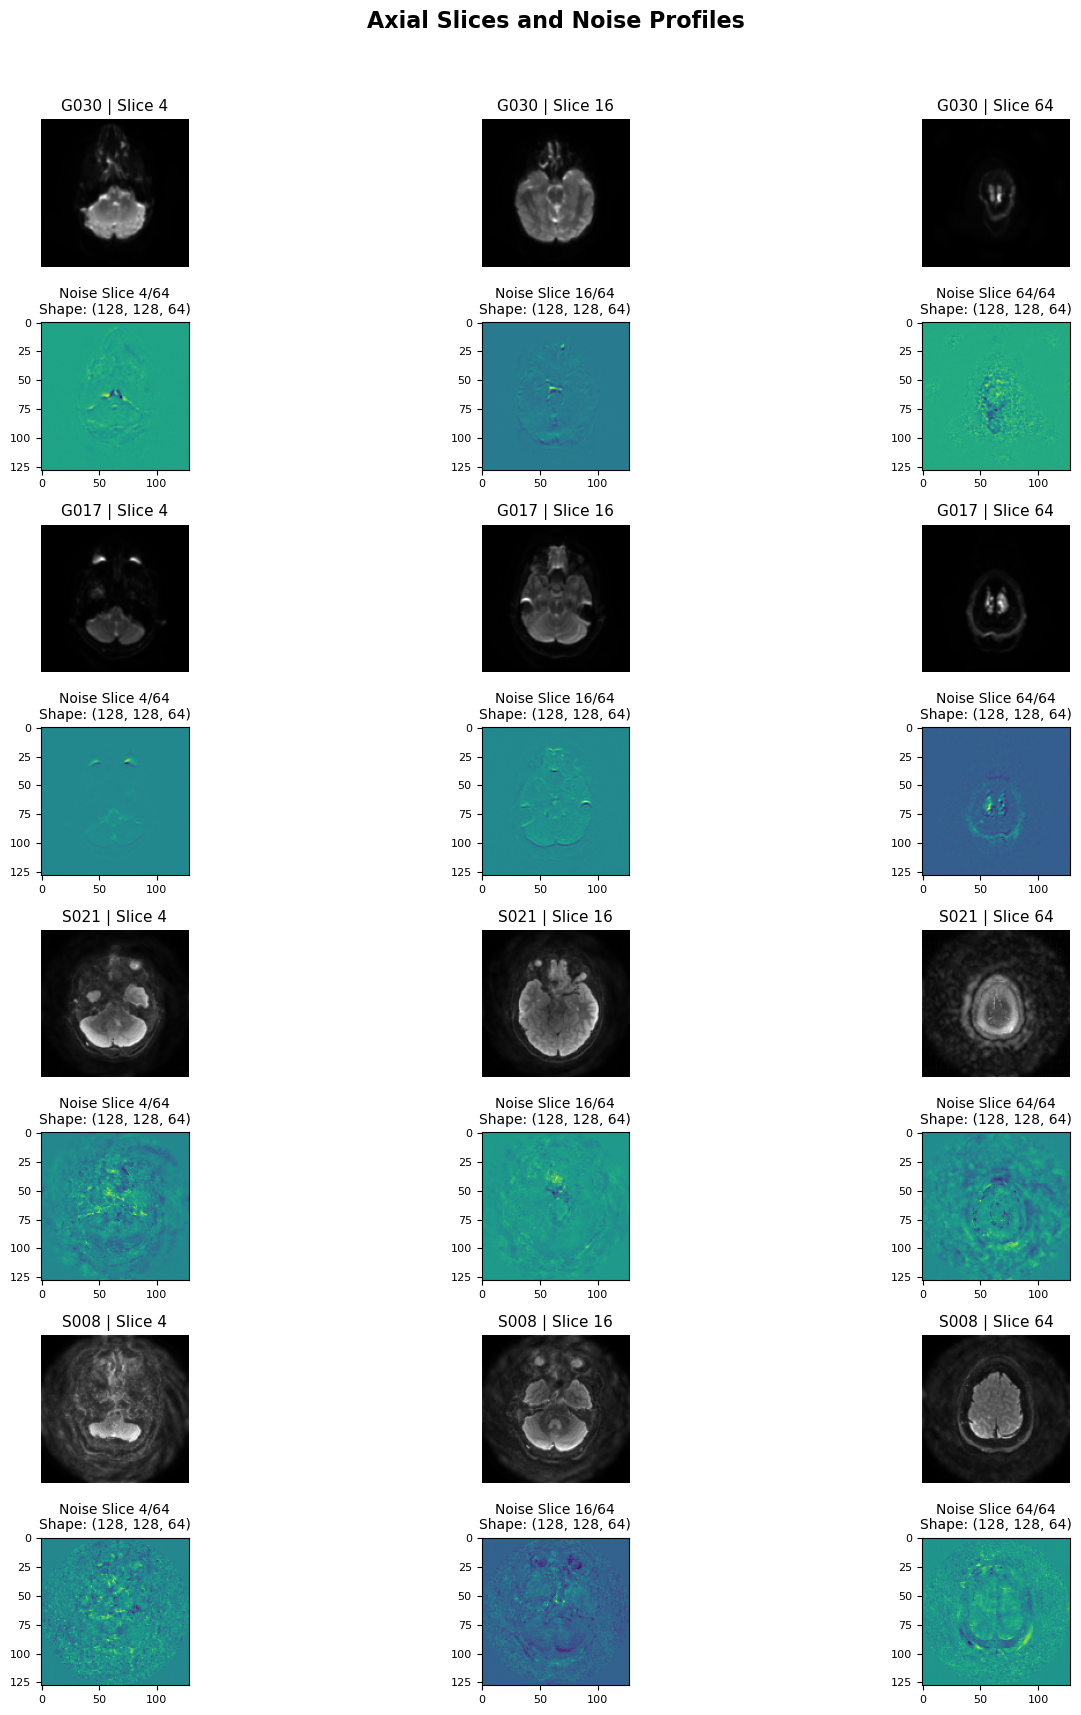

In [3]:
G030 = samples[0]
G017 = samples[1]
S021 = samples[2]
S008 = samples[3]

from models.process_data.plot import *

plot_sample_comparison(
    samples_to_plot=[G030, G017, S021, S008],
    slices_to_show=[3, 15, 63]
)

In [4]:
print_sample_stats(G030)
print_sample_stats(G017)
print_sample_stats(S021)
print_sample_stats(S008)

----------------------------------------
 Statistics for Subject: G030
  Image Shape: (128, 128, 64)
  Noise Shape: (128, 128, 64)
  Noise Range: [0.0000, 1.0000]
  Noise Mean:  0.4049
  Noise Std:   0.0103
----------------------------------------
----------------------------------------
 Statistics for Subject: G017
  Image Shape: (128, 128, 64)
  Noise Shape: (128, 128, 64)
  Noise Range: [0.0000, 1.0000]
  Noise Mean:  0.4693
  Noise Std:   0.0107
----------------------------------------
----------------------------------------
 Statistics for Subject: S021
  Image Shape: (128, 128, 64)
  Noise Shape: (128, 128, 64)
  Noise Range: [0.0000, 1.0000]
  Noise Mean:  0.5386
  Noise Std:   0.0312
----------------------------------------
----------------------------------------
 Statistics for Subject: S008
  Image Shape: (128, 128, 64)
  Noise Shape: (128, 128, 64)
  Noise Range: [0.0000, 1.0000]
  Noise Mean:  0.4272
  Noise Std:   0.0361
----------------------------------------


Third, let's observe the noise pattern of a subject over all the slices

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

# Load the preprocessed dataset
with open('/home/smooi/Desktop/mre_segmentation/data/train/dataset.pkl', 'rb') as f:
    data = pickle.load(f)

samples = data['samples']

# Find a sample with noise (e.g., G030)
subject_to_plot = 'G030'  # Change this to any subject ID you want
sample = None
for s in samples:
    if s['subject_id'] == subject_to_plot and s['noise'] is not None:
        sample = s
        break

if sample is None:
    print(f"Subject {subject_to_plot} not found or has no noise!")
else:
    image = sample['image']
    label = sample['label']
    noise = sample['noise']
    subject_id = sample['subject_id']
    
    print(f"Plotting all slices for {subject_id}")
    print(f"Image shape: {image.shape}")
    print(f"Noise shape: {noise.shape}")
    
    # Get number of slices
    num_slices = image.shape[2]
    
    # Create a large figure with all slices
    # We'll show 8 slices per row
    slices_per_row = 8
    num_rows = int(np.ceil(num_slices / slices_per_row))
    
    # Create figure with 3 rows per slice set (image, label, noise)
    fig, axes = plt.subplots(num_rows * 3, slices_per_row, figsize=(20, num_rows * 6))
    fig.suptitle(f'All Slices for {subject_id} - Image, Label, and Noise', 
                 fontsize=16, fontweight='bold')
    
    # Flatten axes for easier indexing
    if num_rows == 1:
        axes = axes.reshape(3, slices_per_row)
    
    for slice_idx in range(num_slices):
        row_group = (slice_idx // slices_per_row) * 3
        col = slice_idx % slices_per_row
        
        # Image
        axes[row_group, col].imshow(image[:, :, slice_idx], cmap='gray')
        axes[row_group, col].set_title(f'Slice {slice_idx + 1}\nImage', fontsize=9)
        axes[row_group, col].axis('off')
        
        # Label
        axes[row_group + 1, col].imshow(label[:, :, slice_idx], cmap='jet', alpha=0.7)
        axes[row_group + 1, col].set_title(f'Label', fontsize=9)
        axes[row_group + 1, col].axis('off')
        
        # Noise - map to corresponding noise slice
        noise_depth = noise.shape[2]
        noise_slice_idx = int(slice_idx * noise_depth / num_slices)
        noise_slice_idx = min(noise_slice_idx, noise_depth - 1)
        
        im = axes[row_group + 2, col].imshow(noise[:, :, noise_slice_idx], cmap='viridis')
        axes[row_group + 2, col].set_title(f'Noise {noise_slice_idx + 1}', fontsize=9)
        axes[row_group + 2, col].axis('off')
    
    # Hide extra subplots if num_slices is not a multiple of slices_per_row
    total_plots = num_rows * slices_per_row
    for idx in range(num_slices, total_plots):
        row_group = (idx // slices_per_row) * 3
        col = idx % slices_per_row
        axes[row_group, col].axis('off')
        axes[row_group + 1, col].axis('off')
        axes[row_group + 2, col].axis('off')
    
    plt.tight_layout()
    plt.savefig(f'{subject_id}_all_slices_with_noise.png', dpi=150, bbox_inches='tight')
    print(f"\n💾 Saved to: {subject_id}_all_slices_with_noise.png")
    plt.show()
    
    # Also create a more compact version showing overlay
    print("\nCreating compact overlay version...")
    
    fig2, axes2 = plt.subplots(3, num_slices, figsize=(num_slices * 2, 6))
    fig2.suptitle(f'{subject_id} - Compact View (Image + Label Overlay, Noise)', 
                  fontsize=14, fontweight='bold')
    
    if num_slices == 1:
        axes2 = axes2.reshape(3, 1)
    
    for slice_idx in range(num_slices):
        # Row 1: Image
        axes2[0, slice_idx].imshow(image[:, :, slice_idx], cmap='gray')
        axes2[0, slice_idx].set_title(f'Slice {slice_idx + 1}', fontsize=8)
        axes2[0, slice_idx].axis('off')
        
        # Row 2: Image + Label overlay
        axes2[1, slice_idx].imshow(image[:, :, slice_idx], cmap='gray')
        axes2[1, slice_idx].imshow(label[:, :, slice_idx], cmap='jet', alpha=0.5)
        axes2[1, slice_idx].axis('off')
        
        # Row 3: Noise
        noise_slice_idx = int(slice_idx * noise.shape[2] / num_slices)
        noise_slice_idx = min(noise_slice_idx, noise.shape[2] - 1)
        axes2[2, slice_idx].imshow(noise[:, :, noise_slice_idx], cmap='viridis')
        axes2[2, slice_idx].set_title(f'N{noise_slice_idx + 1}', fontsize=8)
        axes2[2, slice_idx].axis('off')
    
    # Add row labels
    axes2[0, 0].text(-0.3, 0.5, 'Image', transform=axes2[0, 0].transAxes,
                     fontsize=12, fontweight='bold', va='center', rotation=90)
    axes2[1, 0].text(-0.3, 0.5, 'Overlay', transform=axes2[1, 0].transAxes,
                     fontsize=12, fontweight='bold', va='center', rotation=90)
    axes2[2, 0].text(-0.3, 0.5, 'Noise', transform=axes2[2, 0].transAxes,
                     fontsize=12, fontweight='bold', va='center', rotation=90)
    
    plt.tight_layout()
    plt.savefig(f'{subject_id}_compact_slices_with_noise.png', dpi=150, bbox_inches='tight')
    print(f"Saved to: {subject_id}_compact_slices_with_noise.png")
    plt.show()


Overlay the mask shape on the noise pattern 